Results are approximately equal: 3.145253723536711e-11
DFT Execution Time: 0.041850 seconds
Cooley-Tuckey Execution Time: 0.007920 seconds


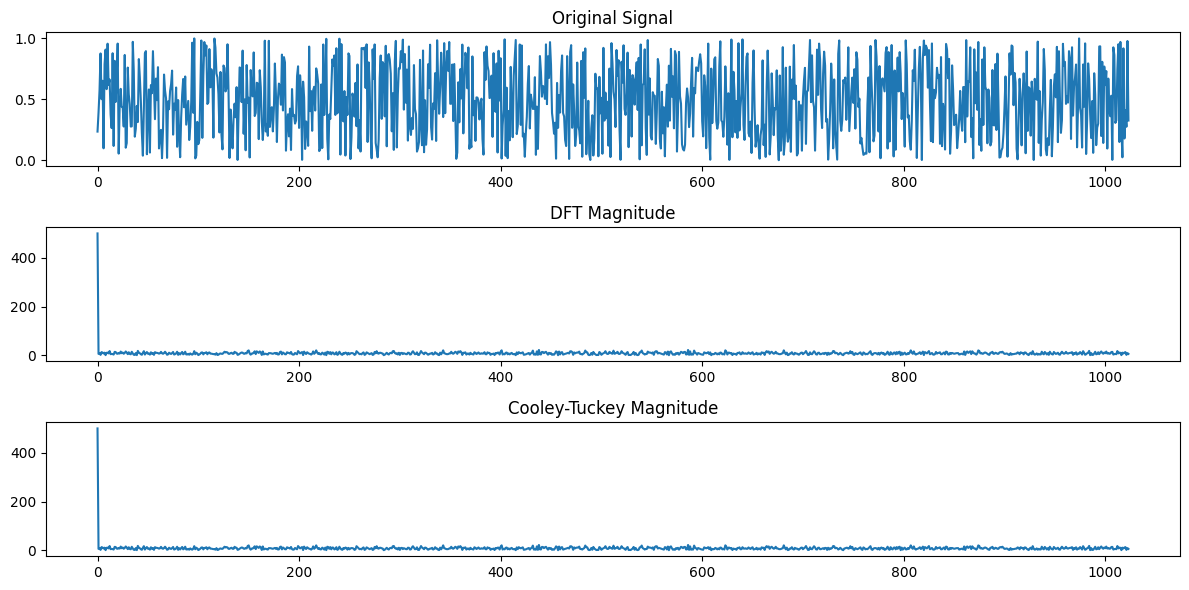

In [ ]:
#Implement the decimation-in-time algorithm (Cooley-Tuckey) using recursion. Compare to your prior DFT implementation both in results and speed.
# The DFT implementation should be O(N^2) while the Cooley-Tuckey algorithm should be O(N log N). You can use the time module to measure the execution time of both algorithms.
# Here is a Python implementation of both the DFT and the Cooley-Tuckey algorithm, along with a comparison of their results and execution times.

import numpy as np
import time

#quick DFT implementation using matrix multiplication
def dft(x):
    """Compute the DFT of a 1D array x using matrix W."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

# decimation in time algorithm (Cooley-Tuckey)
def cooley_tuckey(x):
    N = len(x)
    if N <= 1:
        return x
    even = cooley_tuckey(x[0::2])
    odd = cooley_tuckey(x[1::2])
    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + T[k] for k in range(N // 2)] + [even[k] - T[k] for k in range(N // 2)]

# Generate a random input signal
N = 2**10  # Length of the input signal must be a power of 2 for Cooley-Tuckey
x = np.random.rand(N)
# Measure execution time for DFT
start_time = time.time()
dft_result = dft(x)
dft_time = time.time() - start_time

# Measure execution time for Cooley-Tuckey
start_time = time.time()
cooley_tuckey_result = cooley_tuckey(x)
cooley_tuckey_time = time.time() - start_time

# Compare results
Cooley_Tuckey_accuracy = np.max(np.abs(dft_result - cooley_tuckey_result)) #assuming the dft as ground truth

print(f"Results are approximately equal: {Cooley_Tuckey_accuracy}")
print(f"DFT Execution Time: {dft_time:.6f} seconds")
print(f"Cooley-Tuckey Execution Time: {cooley_tuckey_time:.6f} seconds")

#plot original signal and the DFT and FFT results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(x)
plt.title('Original Signal')
plt.subplot(3, 1, 2)
plt.plot(np.abs(dft_result))
plt.title('DFT Magnitude')
plt.subplot(3, 1, 3)
plt.plot(np.abs(cooley_tuckey_result))
plt.title('Cooley-Tuckey Magnitude')
plt.tight_layout()
plt.show()

Results are approximately equal: 3.145253723536711e-11
Decimation-in-Frequency Execution Time: 0.007488 seconds


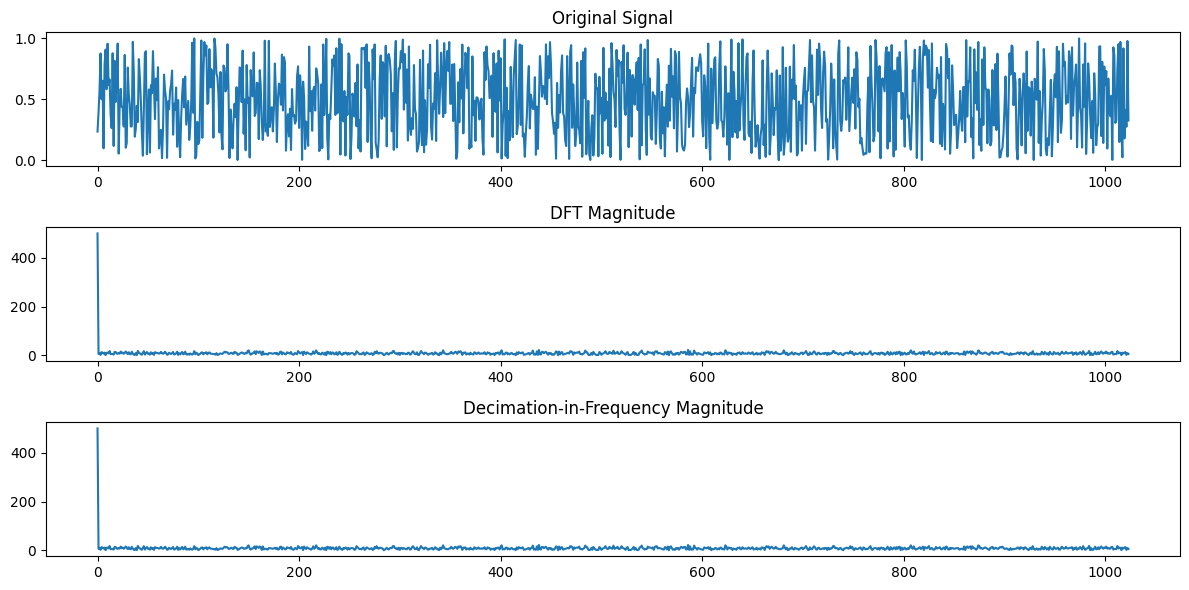

In [4]:
#Implement the decimation-in-frequency approach (very similar code) and compare.

def decimation_in_frequency(x):
    N = len(x)
    if N <= 1:
        return x
    even = decimation_in_frequency(x[0::2])
    odd = decimation_in_frequency(x[1::2])
    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + T[k] for k in range(N // 2)] + [even[k] - T[k] for k in range(N // 2)]

# Measure execution time for Decimation-in-Frequency
start_time = time.time()
decimation_in_frequency_result = decimation_in_frequency(x)
decimation_in_frequency_time = time.time() - start_time

# Compare results
Decimation_in_Frequency_accuracy = np.max(np.abs(dft_result - decimation_in_frequency_result)) #assuming the dft as ground truth
print(f"Results are approximately equal: {Decimation_in_Frequency_accuracy}")
print(f"Decimation-in-Frequency Execution Time: {decimation_in_frequency_time:.6f} seconds")
#plot original signal and the DFT and Decimation-in-Frequency results
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(x)
plt.title('Original Signal')
plt.subplot(3, 1, 2)
plt.plot(np.abs(dft_result))
plt.title('DFT Magnitude')
plt.subplot(3, 1, 3)
plt.plot(np.abs(decimation_in_frequency_result))
plt.title('Decimation-in-Frequency Magnitude')
plt.tight_layout()
plt.show()
